In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os


In [5]:
dataset_path = r"C:\Users\sarik\Raitha Bandava\training\project"

test_dataset_path = dataset_path


def clean_dataset(path):

    deleted = 0

    for root, dirs, files in os.walk(path):

        for file in files:

            file_path = os.path.join(root, file)

            try:

                # Remove non-image files
                if not file.lower().endswith(('.png', '.jpg', '.jpeg')):

                    print("Removing non-image file:", file_path)

                    os.remove(file_path)

                    deleted += 1

                    continue


                # Remove empty files
                if os.path.getsize(file_path) == 0:

                    print("Removing empty file:", file_path)

                    os.remove(file_path)

                    deleted += 1

                    continue


                # Fully load image
                img = Image.open(file_path)

                img.load()


            except Exception as e:

                print("Removing corrupted image:", file_path)

                print("Error:", e)

                os.remove(file_path)

                deleted += 1


    print("\nCleaning completed")

    print("Total removed files:", deleted)


# CLEAN TRAIN DATASET
clean_dataset(dataset_path)

# CLEAN TEST DATASET
clean_dataset(test_dataset_path) 


Cleaning completed
Total removed files: 0

Cleaning completed
Total removed files: 0


In [6]:
BATCH_SIZE=32
IMAGE_SIZE=256
CHANNELS=3
EPOCHS=20

In [7]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)


Found 26937 files belonging to 12 classes.
Using 21550 files for training.


In [8]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 26937 files belonging to 12 classes.
Using 5387 files for validation.


In [9]:
class_names = train_ds.class_names
print(class_names)

['Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Maize_Rust', 'Sugarcane_Bacterial_Blight', 'Sugarcane_Healthy', 'Sugarcane_Mosaic', 'Wheat_Brown_Rust', 'Wheat_Crown_Root_Rot', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Septoria']


In [10]:
train_ds = train_ds.ignore_errors()
val_ds = val_ds.ignore_errors()

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [12]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dataset_path,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = test_ds.apply(tf.data.experimental.ignore_errors())
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 26937 files belonging to 12 classes.
Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [13]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2),

])

In [14]:
base_model = tf.keras.applications.EfficientNetB0(

    input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS),

    include_top=False,

    weights='imagenet'

)


# Freeze pretrained layers
base_model.trainable = False


In [15]:
inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)

x = layers.Dropout(0.5)(x)

x = layers.Dense(128, activation='relu')(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)


In [16]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 8, 8, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 12)                  │           1,548 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,417,071 (16.85 MB)

 Trainable params: 364,940 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [17]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [18]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=2,

    min_lr=0.000001

)

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

    

Epoch 1/20
    674/Unknown 5687s 8s/step - accuracy: 0.4377 - loss: 1.7975

C:\Users\sarik\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


674/674 ━━━━━━━━━━━━━━━━━━━━ 5990s 9s/step - accuracy: 0.5600 - loss: 1.3086 - val_accuracy: 0.7761 - val_loss: 0.5322
Epoch 2/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 1822s 3s/step - accuracy: 0.7163 - loss: 0.7365 - val_accuracy: 0.8162 - val_loss: 0.4186
Epoch 3/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2186s 3s/step - accuracy: 0.7558 - loss: 0.6131 - val_accuracy: 0.8355 - val_loss: 0.3652
Epoch 4/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2176s 3s/step - accuracy: 0.7755 - loss: 0.5438 - val_accuracy: 0.8431 - val_loss: 0.3439
Epoch 5/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 11718s 17s/step - accuracy: 0.7902 - loss: 0.4953 - val_accuracy: 0.8480 - val_loss: 0.3346
Epoch 6/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 1337s 2s/step - accuracy: 0.8026 - loss: 0.4586 - val_accuracy: 0.8550 - val_loss: 0.3151
Epoch 7/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2248s 3s/step - accuracy: 0.8131 - loss: 0.4292 - val_accuracy: 0.8559 - val_loss: 0.3082
Epoch 8/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 39707s 59s/step - accuracy: 0.8176 - loss: 0.4147 - val_acc

In [20]:
score=model.evaluate(test_ds)

842/842 ━━━━━━━━━━━━━━━━━━━━ 918s 1s/step - accuracy: 0.8850 - loss: 0.2392


In [21]:
acc=history.history["accuracy"]
val_acc=history.history["val_accuracy"]

loss=history.history["loss"]
val_loss=history.history["val_loss"]

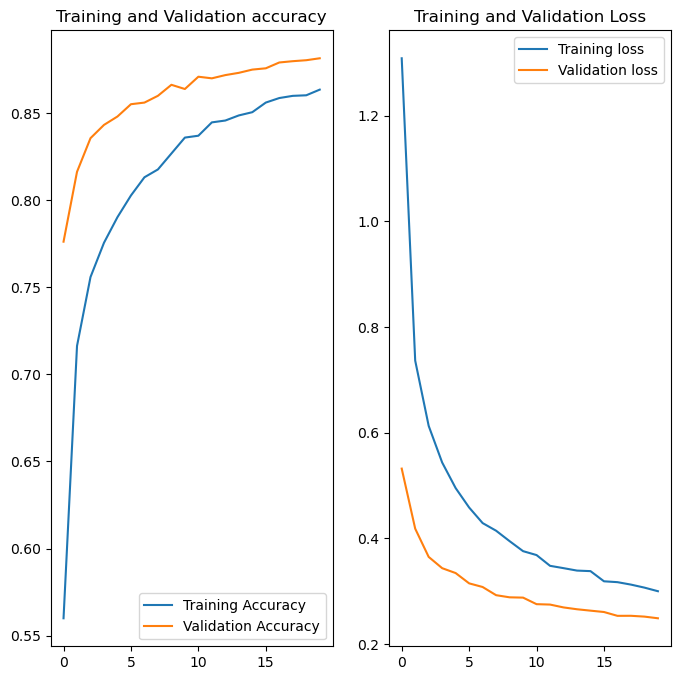

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label="Training Accuracy")
plt.plot(range(EPOCHS),val_acc,label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation accuracy")

plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label="Training loss")
plt.plot(range(EPOCHS),val_loss,label="Validation loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

First image to predict
Actual label: Sugarcane_Bacterial_Blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted label: Sugarcane_Bacterial_Blight


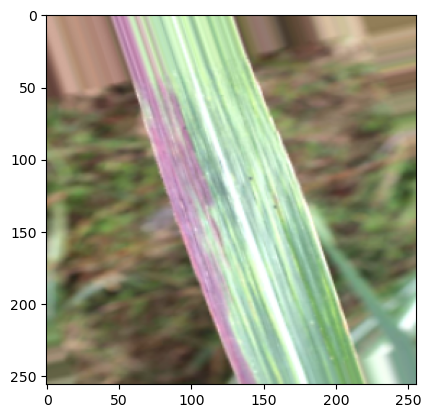

In [25]:
import numpy as np
for images_batch,labels_batch in test_ds.take(1):
    first_image=images_batch[0].numpy().astype("uint8")
    print("First image to predict")
    plt.imshow(first_image)
    print("Actual label:",class_names[labels_batch[0].numpy()])

    batch_prediction=model.predict(images_batch)
    print("Predicted label:",class_names[np.argmax(batch_prediction[0])])

In [26]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)

    predictions=model.predict(img_array)

    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100 * (np.max(predictions[0])),2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


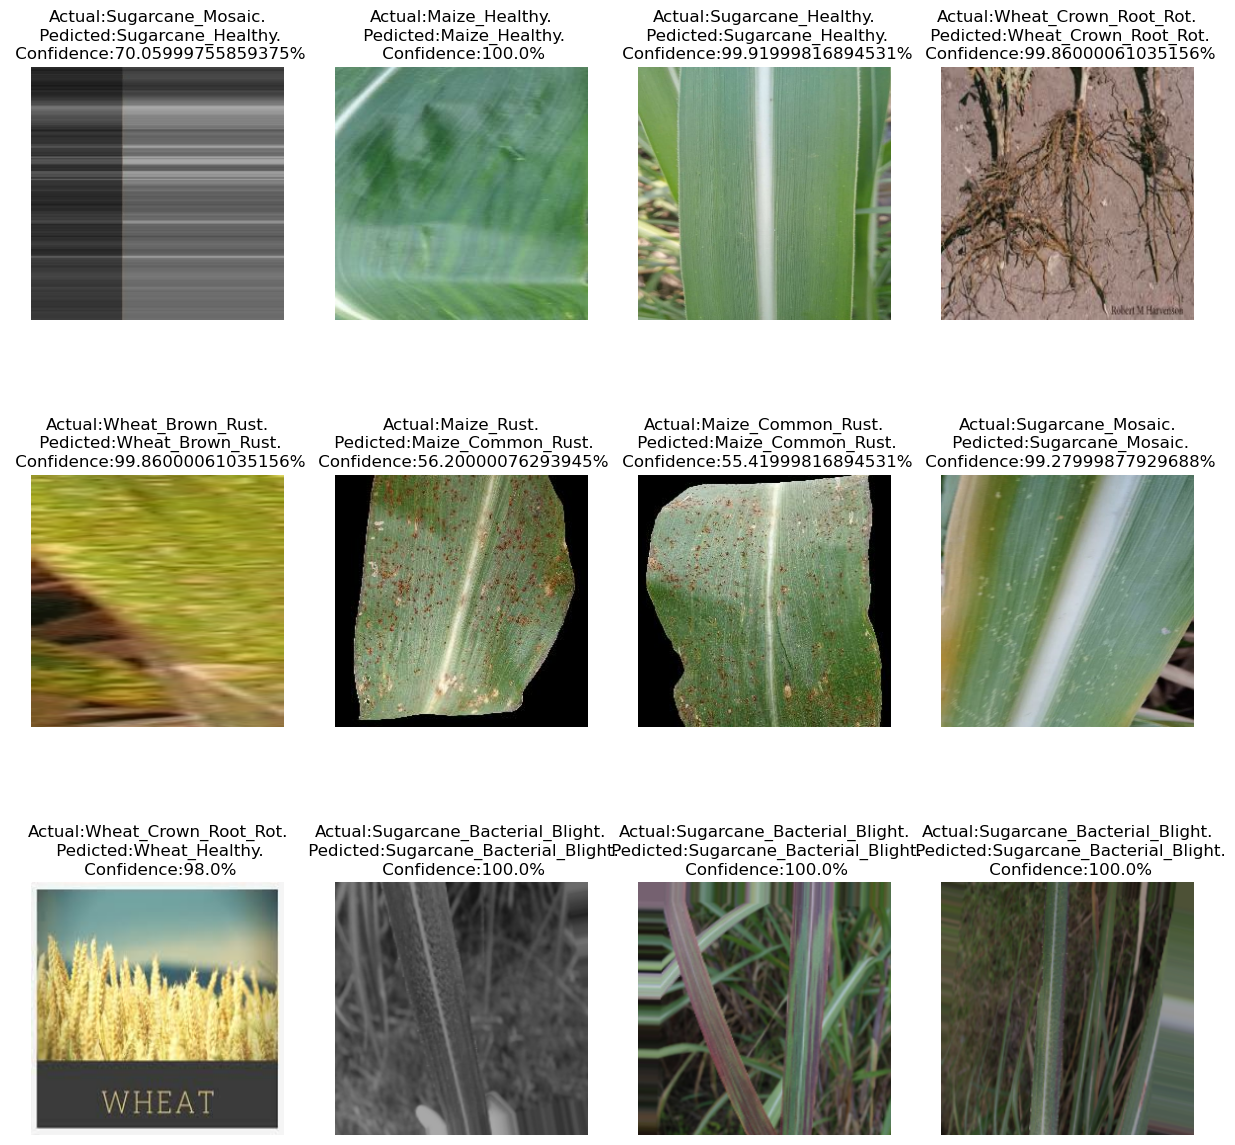

In [27]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class,confidence=predict(model,images[i].numpy())

        actual_class=class_names[labels[i]]

        plt.title(f"Actual:{actual_class}.\n Pedicted:{predicted_class}.\n Confidence:{confidence}%")
        plt.axis("off")

In [33]:
model.save("crop_disease_model.h5")
print("model saved")

TypeError: cannot pickle 'module' object

In [31]:


model.save_weights("crop_disease.weights.h5")

print("Weights saved successfully!")

Weights saved successfully!


In [32]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "crop_disease_model.keras"
)

print("MODEL LOADED")

model.summary()

MODEL LOADED


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 8, 8, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 12)                  │           1,548 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,146,953 (19.63 MB)

 Trainable params: 364,940 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 729,882 (2.78 MB)